# Employee Attrition Prediction with XGBoost (Generalization-Focused)

This notebook is optimized for **better test-set generalization** while still tracking high accuracy.

## Main goals
- Build a robust XGBoost attrition model (`Attrition=1`).
- Improve **generalization** (reduce CV-to-test performance gap).
- Track both:
  - `F1` for attrition class (primary for imbalance)
  - `Accuracy` (secondary, requested for assignment)

## Data inputs
- `outputs/preprocessed_data.csv`
- `outputs/X_train_smote.csv`
- `outputs/X_test.csv`
- `outputs/y_train_smote.csv`
- `outputs/y_test.csv`


## 0) Setup
Install dependencies and set reproducibility constants.


In [31]:
%pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [32]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('Environment ready. RANDOM_STATE =', RANDOM_STATE)


Environment ready. RANDOM_STATE = 42


## 1) Load data and validate contracts
This section validates the assignment files and prepares two training views:
- **SMOTE training split** (existing artifacts)
- **Reconstructed original imbalanced split** (for better generalization tuning)


In [33]:
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'outputs').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 'data/' and 'outputs/' folders.")


def ensure_required_files(root: Path, relative_paths: list[str]) -> dict[str, Path]:
    missing = []
    out = {}
    for rel in relative_paths:
        p = root / rel
        out[rel] = p
        if not p.exists():
            missing.append(str(p))
    if missing:
        raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing))
    return out


def convert_boolean_like_strings(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    converted = []
    out = df.copy()
    for col in out.columns:
        if out[col].dtype == 'object':
            lowered = out[col].dropna().astype(str).str.strip().str.lower()
            vals = set(lowered.unique())
            if vals and vals.issubset({'true', 'false'}):
                out[col] = (
                    out[col]
                    .astype(str)
                    .str.strip()
                    .str.lower()
                    .map({'true': 1, 'false': 0})
                    .astype('int8')
                )
                converted.append(col)
    return out, converted


PROJECT_ROOT = find_project_root(Path.cwd())
print('Project root:', PROJECT_ROOT)

required_files = [
    'outputs/preprocessed_data.csv',
    'outputs/X_train_smote.csv',
    'outputs/X_test.csv',
    'outputs/y_train_smote.csv',
    'outputs/y_test.csv',
]
paths = ensure_required_files(PROJECT_ROOT, required_files)

preprocessed_df = pd.read_csv(paths['outputs/preprocessed_data.csv'])
X_train_smote = pd.read_csv(paths['outputs/X_train_smote.csv'])
X_test = pd.read_csv(paths['outputs/X_test.csv'])
y_train_smote_df = pd.read_csv(paths['outputs/y_train_smote.csv'])
y_test_df = pd.read_csv(paths['outputs/y_test.csv'])

if list(y_train_smote_df.columns) != ['Attrition'] or list(y_test_df.columns) != ['Attrition']:
    raise ValueError("Target column must be exactly 'Attrition' in y_train_smote.csv and y_test.csv.")

if list(X_train_smote.columns) != list(X_test.columns):
    raise ValueError('X_train_smote and X_test columns do not match.')

if X_train_smote.shape[1] != 44:
    raise ValueError(f'Expected 44 features, found {X_train_smote.shape[1]}.')

leak_cols = [c for c in X_train_smote.columns if 'attrition' in c.lower()]
if leak_cols:
    raise ValueError(f'Potential target leakage columns found in X: {leak_cols}')

# Convert boolean-like strings in saved split features
X_train_smote, converted_train_cols = convert_boolean_like_strings(X_train_smote)
X_test, converted_test_cols = convert_boolean_like_strings(X_test)

# Force numeric
for col in X_train_smote.columns:
    if X_train_smote[col].dtype == 'object' or X_test[col].dtype == 'object':
        X_train_smote[col] = pd.to_numeric(X_train_smote[col], errors='raise')
        X_test[col] = pd.to_numeric(X_test[col], errors='raise')

y_train_smote = y_train_smote_df['Attrition'].astype(int)
y_test = y_test_df['Attrition'].astype(int)

if (set(y_train_smote.unique()) - {0, 1}) or (set(y_test.unique()) - {0, 1}):
    raise ValueError('Target values must be binary (0/1).')

# Reconstruct original imbalanced split from preprocessed_data for generalization-first modeling
full_df = preprocessed_df.copy()
if full_df['Attrition'].dtype == 'object':
    full_df['Attrition'] = full_df['Attrition'].map({'Yes': 1, 'No': 0})
full_df['Attrition'] = full_df['Attrition'].astype(int)

X_full = pd.get_dummies(full_df.drop(columns='Attrition'), drop_first=True)
y_full = full_df['Attrition']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE,
)

# Align reconstructed features to saved test feature contract
X_train_raw = X_train_raw.reindex(columns=X_test.columns, fill_value=0)
X_test_raw = X_test_raw.reindex(columns=X_test.columns, fill_value=0)

# Use saved test split as official test, but check reconstructed test similarity for sanity
same_test_size = len(X_test_raw) == len(X_test)
same_test_target_balance = y_test_raw.value_counts().sort_index().to_dict() == y_test.value_counts().sort_index().to_dict()

print('Loaded shapes:')
print('- preprocessed_df:', preprocessed_df.shape)
print('- X_train_smote:', X_train_smote.shape, '| y_train_smote:', y_train_smote.shape)
print('- X_test (official):', X_test.shape, '| y_test:', y_test.shape)
print('- X_train_raw (reconstructed):', X_train_raw.shape, '| y_train_raw:', y_train_raw.shape)
print('- reconstructed test size matches official:', same_test_size)
print('- reconstructed test target balance matches official:', same_test_target_balance)
print('Converted boolean columns:', sorted(set(converted_train_cols + converted_test_cols)))


Project root: /Users/dilandilaruksha/Project/employee-attrition-prediction
Loaded shapes:
- preprocessed_df: (1470, 31)
- X_train_smote: (1972, 44) | y_train_smote: (1972,)
- X_test (official): (294, 44) | y_test: (294,)
- X_train_raw (reconstructed): (1176, 44) | y_train_raw: (1176,)
- reconstructed test size matches official: True
- reconstructed test target balance matches official: True
Converted boolean columns: []


## 2) Data analysis and class-balance context
Show why the previous run overfit: balanced training vs imbalanced test.


In [34]:
print('Preprocessed dataset shape:', preprocessed_df.shape)
print('\nMissing values (total):', int(preprocessed_df.isna().sum().sum()))
print('Duplicate rows:', int(preprocessed_df.duplicated().sum()))

print('\nFull dataset target distribution:')
print(preprocessed_df['Attrition'].value_counts().sort_index())
print((preprocessed_df['Attrition'].value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + '%')

dist = pd.DataFrame({
    'train_smote_count': y_train_smote.value_counts().sort_index(),
    'train_raw_count': y_train_raw.value_counts().sort_index(),
    'test_count': y_test.value_counts().sort_index(),
})
dist['train_smote_pct'] = (dist['train_smote_count'] / dist['train_smote_count'].sum() * 100).round(2)
dist['train_raw_pct'] = (dist['train_raw_count'] / dist['train_raw_count'].sum() * 100).round(2)
dist['test_pct'] = (dist['test_count'] / dist['test_count'].sum() * 100).round(2)

display(dist)


Preprocessed dataset shape: (1470, 31)

Missing values (total): 0
Duplicate rows: 0

Full dataset target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition
0    83.88%
1    16.12%
Name: proportion, dtype: str


,train_smote_count,train_raw_count,test_count,train_smote_pct,train_raw_pct,test_pct
Attrition,,,,,,
0,986,986,247,50.0,83.84,84.01
1,986,190,47,50.0,16.16,15.99


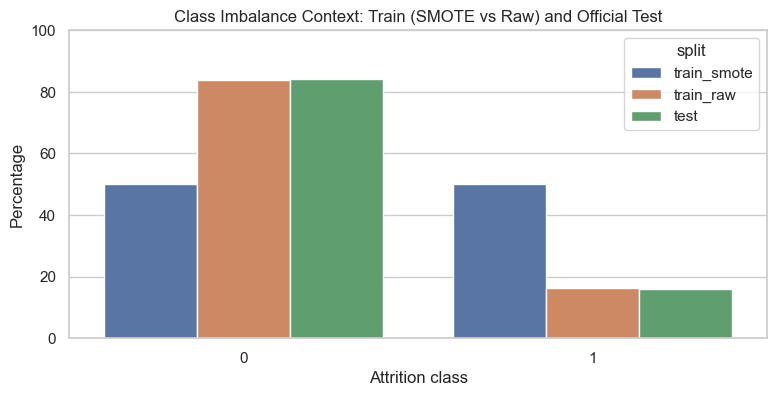

In [35]:
plot_df = pd.DataFrame({
    'split': ['train_smote', 'train_raw', 'test'] * 2,
    'class': [0, 0, 0, 1, 1, 1],
    'pct': [
        (y_train_smote == 0).mean() * 100,
        (y_train_raw == 0).mean() * 100,
        (y_test == 0).mean() * 100,
        (y_train_smote == 1).mean() * 100,
        (y_train_raw == 1).mean() * 100,
        (y_test == 1).mean() * 100,
    ]
})

plt.figure(figsize=(9, 4))
sns.barplot(data=plot_df, x='class', y='pct', hue='split')
plt.title('Class Imbalance Context: Train (SMOTE vs Raw) and Official Test')
plt.xlabel('Attrition class')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.show()


## 3) Baseline checks
Compare the old-style SMOTE-trained baseline vs a raw-train weighted baseline.


In [36]:
def evaluate_from_probabilities(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> tuple[dict, np.ndarray]:
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'threshold': float(threshold),
        'f1': float(f1_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'pr_auc': float(average_precision_score(y_true, y_prob)),
    }
    return metrics, y_pred


# Baseline A: train on SMOTE data (previous style)
baseline_smote = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)
baseline_smote.fit(X_train_smote, y_train_smote)
baseline_smote_prob = baseline_smote.predict_proba(X_test)[:, 1]
baseline_smote_metrics, baseline_smote_pred = evaluate_from_probabilities(y_test, baseline_smote_prob, threshold=0.50)

# Baseline B: train on imbalanced raw data with class weighting
neg, pos = np.bincount(y_train_raw)
base_scale_pos_weight = float(neg / pos)

baseline_raw_weighted = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    scale_pos_weight=base_scale_pos_weight,
)
baseline_raw_weighted.fit(X_train_raw, y_train_raw)
baseline_raw_prob = baseline_raw_weighted.predict_proba(X_test)[:, 1]
baseline_raw_metrics, baseline_raw_pred = evaluate_from_probabilities(y_test, baseline_raw_prob, threshold=0.50)

baseline_compare = pd.DataFrame([
    {'model': 'Baseline_SMOTE_train', **baseline_smote_metrics},
    {'model': 'Baseline_RawWeighted_train', **baseline_raw_metrics},
])

display(baseline_compare.round(4))
print('Base scale_pos_weight from raw train:', round(base_scale_pos_weight, 4))


,model,threshold,f1,precision,recall,accuracy,roc_auc,pr_auc
0,Baseline_SMOTE_train,0.5,0.4167,0.6000,0.3191,0.8571,0.7367,0.4183
1,Baseline_RawWeighted_train,0.5,0.4935,0.6333,0.4043,0.8673,0.7473,0.4863


Base scale_pos_weight from raw train: 5.1895


## 4) Generalization-focused heavy tuning (two-stage)
Tune on **raw imbalanced train split** with class weighting and regularization-focused search spaces.


In [37]:
# Holdout validation split for threshold selection only (never touch test)
X_tune, X_val, y_tune, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.20,
    stratify=y_train_raw,
    random_state=RANDOM_STATE,
)

neg_tune, pos_tune = np.bincount(y_tune)
scale_pos_weight_tune = float(neg_tune / pos_tune)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)

param_dist_stage1 = {
    'n_estimators': [300, 500, 700, 900, 1200, 1500],
    'max_depth': [2, 3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.12],
    'min_child_weight': [1, 2, 3, 5, 7, 10],
    'subsample': [0.60, 0.70, 0.80, 0.90, 1.00],
    'colsample_bytree': [0.50, 0.60, 0.70, 0.80, 0.90, 1.00],
    'gamma': [0.0, 0.1, 0.2, 0.4, 0.8, 1.2],
    'reg_alpha': [0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
    'reg_lambda': [1.0, 2.0, 3.0, 5.0, 8.0, 12.0],
    'scale_pos_weight': [
        round(scale_pos_weight_tune * 0.75, 4),
        round(scale_pos_weight_tune * 0.90, 4),
        round(scale_pos_weight_tune, 4),
        round(scale_pos_weight_tune * 1.10, 4),
        round(scale_pos_weight_tune * 1.25, 4),
    ],
}

stage1_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_stage1,
    n_iter=200,
    scoring='f1',
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
)

stage1_search.fit(X_tune, y_tune)

print('Stage 1 best CV F1:', round(stage1_search.best_score_, 5))
print('Stage 1 best params:')
print(stage1_search.best_params_)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Stage 1 best CV F1: 0.58354
Stage 1 best params:
{'subsample': 0.8, 'scale_pos_weight': 3.8882, 'reg_lambda': 2.0, 'reg_alpha': 0.05, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 2, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.6}


In [38]:
def refine_int(value: int, min_value: int, max_value: int, step: int = 1) -> list[int]:
    values = [value - 2 * step, value - step, value, value + step, value + 2 * step]
    values = [min(max(v, min_value), max_value) for v in values]
    return sorted(set(int(v) for v in values))


def refine_float(value: float, min_value: float, max_value: float, mult=(0.70, 0.85, 1.00, 1.15, 1.30), ndigits: int = 4) -> list[float]:
    values = [value * m for m in mult]
    values = [min(max(v, min_value), max_value) for v in values]
    return sorted(set(round(float(v), ndigits) for v in values))


best1 = stage1_search.best_params_

param_dist_stage2 = {
    'n_estimators': refine_int(best1['n_estimators'], min_value=200, max_value=2000, step=100),
    'max_depth': refine_int(best1['max_depth'], min_value=2, max_value=10, step=1),
    'learning_rate': refine_float(best1['learning_rate'], min_value=0.005, max_value=0.20),
    'min_child_weight': refine_int(best1['min_child_weight'], min_value=1, max_value=20, step=1),
    'subsample': refine_float(best1['subsample'], min_value=0.50, max_value=1.00),
    'colsample_bytree': refine_float(best1['colsample_bytree'], min_value=0.40, max_value=1.00),
    'gamma': sorted(set([0.0] + refine_float(best1['gamma'], min_value=0.0, max_value=3.0))),
    'reg_alpha': sorted(set([0.0] + refine_float(best1['reg_alpha'], min_value=0.0, max_value=5.0))),
    'reg_lambda': refine_float(best1['reg_lambda'], min_value=0.5, max_value=20.0),
    'scale_pos_weight': refine_float(best1['scale_pos_weight'], min_value=1.0, max_value=20.0),
}

stage2_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_stage2,
    n_iter=80,
    scoring='f1',
    n_jobs=-1,
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
)

stage2_search.fit(X_tune, y_tune)

print('Stage 2 best CV F1:', round(stage2_search.best_score_, 5))
print('Stage 2 best params:')
print(stage2_search.best_params_)

cv_compare = pd.DataFrame({
    'stage': ['stage1', 'stage2'],
    'best_cv_f1': [stage1_search.best_score_, stage2_search.best_score_],
})
display(cv_compare)


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Stage 2 best CV F1: 0.58854
Stage 2 best params:
{'subsample': 0.92, 'scale_pos_weight': 4.4714, 'reg_lambda': 1.7, 'reg_alpha': 0.05, 'n_estimators': 400, 'min_child_weight': 11, 'max_depth': 3, 'learning_rate': 0.0255, 'gamma': 0.26, 'colsample_bytree': 0.69}


,stage,best_cv_f1
0,stage1,0.583543
1,stage2,0.588542


## 5) Threshold tuning (robust F1 + max Accuracy)
Thresholds are selected on **validation split only** to avoid test leakage.

For F1, we use a robust policy:
- maximize F1 under a minimum recall constraint
- tie-break by distance to 0.50 (stability)

This avoids unstable, overly-conservative thresholds that can fail on test data.


Raw validation max-F1 threshold: 0.69
Selected robust F1 threshold: 0.58
Selected accuracy threshold: 0.69
F1 threshold policy: max_f1_with_recall_constraint_and_stability_tiebreak


,threshold,f1,accuracy,precision,recall
66,0.71,0.586207,0.898305,0.850000,0.447368
65,0.70,0.586207,0.898305,0.850000,0.447368
64,0.69,0.586207,0.898305,0.850000,0.447368
63,0.68,0.566667,0.889831,0.772727,0.447368
53,0.58,0.563380,0.868644,0.606061,0.526316
62,0.67,0.557377,0.885593,0.739130,0.447368
61,0.66,0.557377,0.885593,0.739130,0.447368
50,0.55,0.552632,0.855932,0.552632,0.552632
49,0.54,0.552632,0.855932,0.552632,0.552632
51,0.56,0.552632,0.855932,0.552632,0.552632


,threshold,f1,accuracy,precision,recall
64,0.69,0.586207,0.898305,0.850000,0.447368
65,0.70,0.586207,0.898305,0.850000,0.447368
66,0.71,0.586207,0.898305,0.850000,0.447368
63,0.68,0.566667,0.889831,0.772727,0.447368
67,0.72,0.535714,0.889831,0.833333,0.394737
69,0.74,0.490566,0.885593,0.866667,0.342105
61,0.66,0.557377,0.885593,0.739130,0.447368
62,0.67,0.557377,0.885593,0.739130,0.447368
68,0.73,0.490566,0.885593,0.866667,0.342105
70,0.75,0.490566,0.885593,0.866667,0.342105


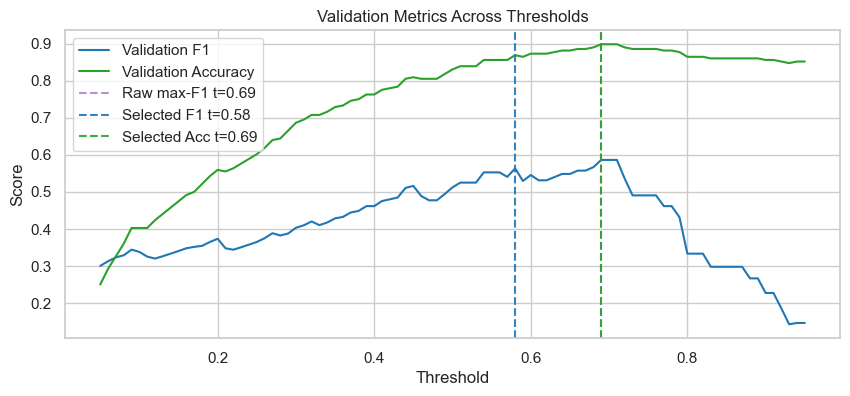

In [39]:
best_params = stage2_search.best_params_

threshold_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    **best_params,
)
threshold_model.fit(X_tune, y_tune)

val_prob = threshold_model.predict_proba(X_val)[:, 1]
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)

rows = []
for t in thresholds:
    y_pred = (val_prob >= t).astype(int)
    rows.append({
        'threshold': float(t),
        'f1': f1_score(y_val, y_pred),
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred, zero_division=0),
        'recall': recall_score(y_val, y_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)

# Raw max-F1 threshold (for diagnostics)
best_f1_validation_row = threshold_df.loc[threshold_df['f1'].idxmax()]
best_threshold_f1_validation = float(best_f1_validation_row['threshold'])

# Robust F1 threshold policy
min_recall_for_f1 = 0.50
eligible = threshold_df[threshold_df['recall'] >= min_recall_for_f1].copy()

if eligible.empty:
    selected_f1_row = best_f1_validation_row.copy()
    threshold_selection_policy = 'fallback_raw_max_f1_no_recall_constraint'
else:
    max_f1_eligible = eligible['f1'].max()
    near_best = eligible[eligible['f1'] >= (max_f1_eligible - 1e-12)].copy()
    near_best['distance_from_0_50'] = (near_best['threshold'] - 0.50).abs()
    selected_f1_row = near_best.sort_values(
        ['distance_from_0_50', 'accuracy', 'threshold'],
        ascending=[True, False, True],
    ).iloc[0]
    threshold_selection_policy = 'max_f1_with_recall_constraint_and_stability_tiebreak'

best_threshold_f1 = float(selected_f1_row['threshold'])

# Accuracy threshold
best_acc_row = threshold_df.loc[threshold_df['accuracy'].idxmax()]
best_threshold_acc = float(best_acc_row['threshold'])

print('Raw validation max-F1 threshold:', best_threshold_f1_validation)
print('Selected robust F1 threshold:', best_threshold_f1)
print('Selected accuracy threshold:', best_threshold_acc)
print('F1 threshold policy:', threshold_selection_policy)

display(threshold_df.sort_values('f1', ascending=False).head(12))
display(threshold_df.sort_values('accuracy', ascending=False).head(12))

plt.figure(figsize=(10, 4))
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='Validation F1', color='tab:blue')
plt.plot(threshold_df['threshold'], threshold_df['accuracy'], label='Validation Accuracy', color='tab:green')
plt.axvline(best_threshold_f1_validation, color='tab:purple', linestyle='--', alpha=0.7, label=f'Raw max-F1 t={best_threshold_f1_validation:.2f}')
plt.axvline(best_threshold_f1, color='tab:blue', linestyle='--', alpha=0.9, label=f'Selected F1 t={best_threshold_f1:.2f}')
plt.axvline(best_threshold_acc, color='tab:green', linestyle='--', alpha=0.9, label=f'Selected Acc t={best_threshold_acc:.2f}')
plt.title('Validation Metrics Across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()


## 6) Final test evaluation
Train on full raw training split and evaluate official test set.
Report:
- threshold `0.50`
- raw validation max-F1 threshold (diagnostic)
- selected robust F1 threshold
- selected accuracy threshold


,model,evaluation,threshold,f1,precision,recall,accuracy,roc_auc,pr_auc
0,Baseline_SMOTE_train,threshold=0.50,0.50,0.4167,0.6000,0.3191,0.8571,0.7367,0.4183
1,Baseline_RawWeighted_train,threshold=0.50,0.50,0.4935,0.6333,0.4043,0.8673,0.7473,0.4863
2,Tuned_RawWeighted,threshold=0.50,0.50,0.4717,0.4237,0.5319,0.8095,0.7913,0.5296
3,Tuned_RawWeighted,threshold_f1_validation_max=0.69,0.69,0.4179,0.7000,0.2979,0.8673,0.7913,0.5296
4,Tuned_RawWeighted,threshold_f1_selected=0.58,0.58,0.4783,0.4889,0.4681,0.8367,0.7913,0.5296
5,Tuned_RawWeighted,threshold_acc_selected=0.69,0.69,0.4179,0.7000,0.2979,0.8673,0.7913,0.5296


Classification report (threshold=0.50):
              precision    recall  f1-score   support

           0     0.9064    0.8623    0.8838       247
           1     0.4237    0.5319    0.4717        47

    accuracy                         0.8095       294
   macro avg     0.6651    0.6971    0.6778       294
weighted avg     0.8292    0.8095    0.8179       294

Classification report (raw validation max-F1 threshold):
              precision    recall  f1-score   support

           0     0.8796    0.9757    0.9251       247
           1     0.7000    0.2979    0.4179        47

    accuracy                         0.8673       294
   macro avg     0.7898    0.6368    0.6715       294
weighted avg     0.8509    0.8673    0.8441       294

Classification report (selected robust F1 threshold):
              precision    recall  f1-score   support

           0     0.8996    0.9069    0.9032       247
           1     0.4889    0.4681    0.4783        47

    accuracy                   

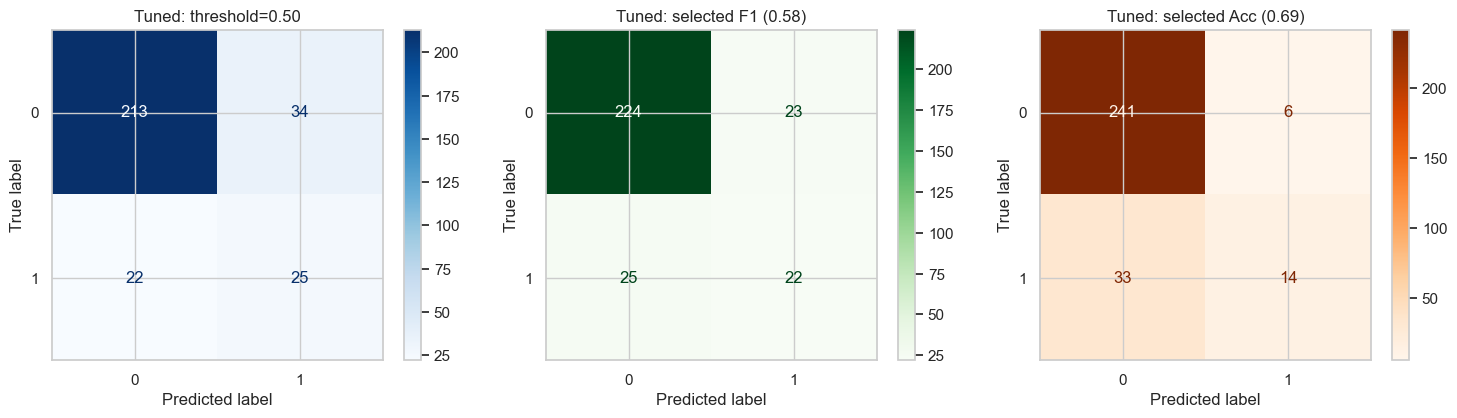

In [40]:
final_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
    **best_params,
)
final_model.fit(X_train_raw, y_train_raw)

test_prob = final_model.predict_proba(X_test)[:, 1]

final_metrics_050, pred_050 = evaluate_from_probabilities(y_test, test_prob, 0.50)
final_metrics_f1_validation, pred_f1_validation = evaluate_from_probabilities(y_test, test_prob, best_threshold_f1_validation)
final_metrics_f1t, pred_f1t = evaluate_from_probabilities(y_test, test_prob, best_threshold_f1)
final_metrics_acct, pred_acct = evaluate_from_probabilities(y_test, test_prob, best_threshold_acc)

results = pd.DataFrame([
    {'model': 'Baseline_SMOTE_train', 'evaluation': 'threshold=0.50', **baseline_smote_metrics},
    {'model': 'Baseline_RawWeighted_train', 'evaluation': 'threshold=0.50', **baseline_raw_metrics},
    {'model': 'Tuned_RawWeighted', 'evaluation': 'threshold=0.50', **final_metrics_050},
    {'model': 'Tuned_RawWeighted', 'evaluation': f'threshold_f1_validation_max={best_threshold_f1_validation:.2f}', **final_metrics_f1_validation},
    {'model': 'Tuned_RawWeighted', 'evaluation': f'threshold_f1_selected={best_threshold_f1:.2f}', **final_metrics_f1t},
    {'model': 'Tuned_RawWeighted', 'evaluation': f'threshold_acc_selected={best_threshold_acc:.2f}', **final_metrics_acct},
])

display(results.round(4))

print('Classification report (threshold=0.50):')
print(classification_report(y_test, pred_050, digits=4))
print('Classification report (raw validation max-F1 threshold):')
print(classification_report(y_test, pred_f1_validation, digits=4))
print('Classification report (selected robust F1 threshold):')
print(classification_report(y_test, pred_f1t, digits=4))
print('Classification report (selected Accuracy threshold):')
print(classification_report(y_test, pred_acct, digits=4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_050, ax=axes[0], cmap='Blues')
axes[0].set_title('Tuned: threshold=0.50')
ConfusionMatrixDisplay.from_predictions(y_test, pred_f1t, ax=axes[1], cmap='Greens')
axes[1].set_title(f'Tuned: selected F1 ({best_threshold_f1:.2f})')
ConfusionMatrixDisplay.from_predictions(y_test, pred_acct, ax=axes[2], cmap='Oranges')
axes[2].set_title(f'Tuned: selected Acc ({best_threshold_acc:.2f})')
plt.tight_layout()
plt.show()


## 7) Generalization gap diagnostics
Compare CV best score with test performance to verify improved robustness.


In [41]:
diag = pd.DataFrame([
    {
        'metric': 'CV best F1 (Stage 2)',
        'value': float(stage2_search.best_score_),
    },
    {
        'metric': 'Test F1 @ threshold=0.50',
        'value': float(final_metrics_050['f1']),
    },
    {
        'metric': 'Test F1 @ raw validation max-F1 threshold',
        'value': float(final_metrics_f1_validation['f1']),
    },
    {
        'metric': 'Test F1 @ selected robust F1 threshold',
        'value': float(final_metrics_f1t['f1']),
    },
    {
        'metric': 'Test Accuracy @ selected accuracy threshold',
        'value': float(final_metrics_acct['accuracy']),
    },
])

cv_test_gap = float(stage2_search.best_score_ - final_metrics_f1t['f1'])
print('CV-to-Test F1 gap (selected robust threshold):', round(cv_test_gap, 4))
display(diag.round(4))


CV-to-Test F1 gap (selected robust threshold): 0.1103


,metric,value
0,CV best F1 (Stage 2),0.5885
1,Test F1 @ threshold=0.50,0.4717
2,Test F1 @ raw validation max-F1 threshold,0.4179
3,Test F1 @ selected robust F1 threshold,0.4783
4,Test Accuracy @ selected accuracy threshold,0.8673


## 8) Explainability and error analysis
Feature importance and focused review of false negatives / false positives.


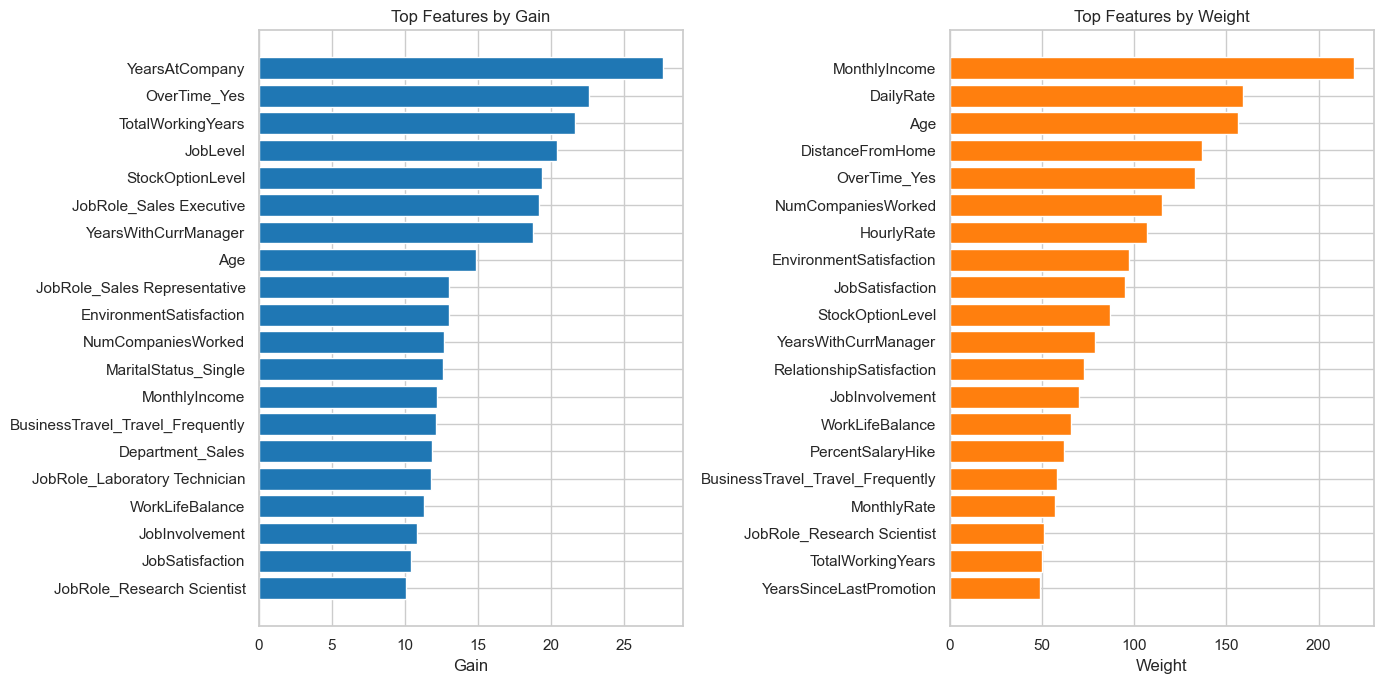

,gain
YearsAtCompany,27.623049
OverTime_Yes,22.597595
TotalWorkingYears,21.628660
JobLevel,20.410927
StockOptionLevel,19.370678
JobRole_Sales Executive,19.148361
YearsWithCurrManager,18.765842
Age,14.849803
JobRole_Sales Representative,13.039206
EnvironmentSatisfaction,13.021646


,weight
MonthlyIncome,219.0
DailyRate,159.0
Age,156.0
DistanceFromHome,137.0
OverTime_Yes,133.0
NumCompaniesWorked,115.0
HourlyRate,107.0
EnvironmentSatisfaction,97.0
JobSatisfaction,95.0
StockOptionLevel,87.0


In [42]:
booster = final_model.get_booster()

gain = pd.Series(booster.get_score(importance_type='gain'), name='gain')
weight = pd.Series(booster.get_score(importance_type='weight'), name='weight')


def remap_findex(series: pd.Series, columns: pd.Index) -> pd.Series:
    if series.empty:
        return series
    if series.index.to_series().str.match(r'^f\d+$').all():
        mapping = {f'f{i}': col for i, col in enumerate(columns)}
        series.index = series.index.map(lambda x: mapping.get(x, x))
    return series

gain = remap_findex(gain, X_train_raw.columns).sort_values(ascending=False)
weight = remap_findex(weight, X_train_raw.columns).sort_values(ascending=False)

top_gain = gain.head(20).sort_values()
top_weight = weight.head(20).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
if not top_gain.empty:
    axes[0].barh(top_gain.index, top_gain.values, color='tab:blue')
axes[0].set_title('Top Features by Gain')
axes[0].set_xlabel('Gain')

if not top_weight.empty:
    axes[1].barh(top_weight.index, top_weight.values, color='tab:orange')
axes[1].set_title('Top Features by Weight')
axes[1].set_xlabel('Weight')

plt.tight_layout()
plt.show()

display(gain.head(10).to_frame())
display(weight.head(10).to_frame())


In [43]:
# Analyze errors at best-F1 threshold
analysis_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_prob': test_prob,
    'y_pred': pred_f1t,
}, index=X_test.index)

conditions = [
    (analysis_df['y_true'] == 1) & (analysis_df['y_pred'] == 0),
    (analysis_df['y_true'] == 0) & (analysis_df['y_pred'] == 1),
]
labels = ['False Negative', 'False Positive']
analysis_df['error_type'] = np.select(conditions, labels, default='Correct')

print('Error distribution (best-F1 threshold):')
print(analysis_df['error_type'].value_counts())

display(analysis_df[analysis_df['error_type'] == 'False Negative'].sort_values('y_prob', ascending=False).head(10))
display(analysis_df[analysis_df['error_type'] == 'False Positive'].sort_values('y_prob', ascending=False).head(10))


Error distribution (best-F1 threshold):
error_type
Correct           246
False Negative     25
False Positive     23
Name: count, dtype: int64


,y_true,y_prob,y_pred,error_type
127,1,0.532015,0,False Negative
196,1,0.503260,0,False Negative
238,1,0.502229,0,False Negative
270,1,0.476040,0,False Negative
291,1,0.464691,0,False Negative
178,1,0.434983,0,False Negative
4,1,0.428154,0,False Negative
108,1,0.396646,0,False Negative
176,1,0.382797,0,False Negative
155,1,0.377044,0,False Negative


,y_true,y_prob,y_pred,error_type
223,0,0.887281,1,False Positive
135,0,0.859728,1,False Positive
199,0,0.791047,1,False Positive
204,0,0.748985,1,False Positive
96,0,0.747535,1,False Positive
9,0,0.703862,1,False Positive
94,0,0.667110,1,False Positive
128,0,0.665370,1,False Positive
226,0,0.662186,1,False Positive
15,0,0.661889,1,False Positive


## 9) Export artifacts
Save metrics, predictions, and model for your report and submission evidence.


In [44]:
metrics_dir = PROJECT_ROOT / 'outputs' / 'metrics'
preds_dir = PROJECT_ROOT / 'outputs' / 'predictions'
models_dir = PROJECT_ROOT / 'outputs' / 'models'

for d in [metrics_dir, preds_dir, models_dir]:
    d.mkdir(parents=True, exist_ok=True)

final_results_table = results.copy()

metrics_payload = {
    'baseline_smote_threshold_0_50': baseline_smote_metrics,
    'baseline_raw_weighted_threshold_0_50': baseline_raw_metrics,
    'tuned_threshold_0_50': final_metrics_050,
    'tuned_threshold_f1_validation_max': final_metrics_f1_validation,
    'tuned_threshold_f1_selected': final_metrics_f1t,
    'tuned_threshold_accuracy_selected': final_metrics_acct,
    'best_threshold_f1_validation_max': best_threshold_f1_validation,
    'best_threshold_f1_selected': best_threshold_f1,
    'best_threshold_accuracy_selected': best_threshold_acc,
    'f1_threshold_selection_policy': threshold_selection_policy,
    'best_params_stage2': best_params,
    'cv_best_score_stage1_f1': float(stage1_search.best_score_),
    'cv_best_score_stage2_f1': float(stage2_search.best_score_),
    'created_utc': pd.Timestamp.utcnow().isoformat(),
}

metrics_path = metrics_dir / 'xgboost_metrics.json'
preds_path = preds_dir / 'xgboost_test_predictions.csv'
model_path = models_dir / 'xgboost_attrition_model.joblib'

with metrics_path.open('w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2)

pred_export = pd.DataFrame({
    'index': X_test.index,
    'y_true': y_test.values,
    'y_prob': test_prob,
    'y_pred_0_50': pred_050,
    'y_pred_f1_validation_max': pred_f1_validation,
    'y_pred_f1_selected': pred_f1t,
    'y_pred_accuracy_selected': pred_acct,
    'error_type_best_f1_selected': analysis_df['error_type'].values,
})
pred_export.to_csv(preds_path, index=False)

joblib.dump(final_model, model_path)

print('Saved:')
print('-', metrics_path)
print('-', preds_path)
print('-', model_path)

display(final_results_table.round(4))


Saved:
- /Users/dilandilaruksha/Project/employee-attrition-prediction/outputs/metrics/xgboost_metrics.json
- /Users/dilandilaruksha/Project/employee-attrition-prediction/outputs/predictions/xgboost_test_predictions.csv
- /Users/dilandilaruksha/Project/employee-attrition-prediction/outputs/models/xgboost_attrition_model.joblib


,model,evaluation,threshold,f1,precision,recall,accuracy,roc_auc,pr_auc
0,Baseline_SMOTE_train,threshold=0.50,0.50,0.4167,0.6000,0.3191,0.8571,0.7367,0.4183
1,Baseline_RawWeighted_train,threshold=0.50,0.50,0.4935,0.6333,0.4043,0.8673,0.7473,0.4863
2,Tuned_RawWeighted,threshold=0.50,0.50,0.4717,0.4237,0.5319,0.8095,0.7913,0.5296
3,Tuned_RawWeighted,threshold_f1_validation_max=0.69,0.69,0.4179,0.7000,0.2979,0.8673,0.7913,0.5296
4,Tuned_RawWeighted,threshold_f1_selected=0.58,0.58,0.4783,0.4889,0.4681,0.8367,0.7913,0.5296
5,Tuned_RawWeighted,threshold_acc_selected=0.69,0.69,0.4179,0.7000,0.2979,0.8673,0.7913,0.5296


## 10) Final interpretation
Use this section in your report presentation.


In [45]:
tuned_only = results[results['model'] == 'Tuned_RawWeighted'].copy()

best_tuned_f1_row = tuned_only.loc[tuned_only['f1'].idxmax()]
best_tuned_acc_row = tuned_only.loc[tuned_only['accuracy'].idxmax()]

summary_lines = [
    f"Best tuned test F1 among evaluated thresholds: {best_tuned_f1_row['f1']:.4f} ({best_tuned_f1_row['evaluation']})",
    f"Best tuned test Accuracy among evaluated thresholds: {best_tuned_acc_row['accuracy']:.4f} ({best_tuned_acc_row['evaluation']})",
    f"Selected robust F1 threshold: {best_threshold_f1:.2f}",
    f"Selected accuracy threshold: {best_threshold_acc:.2f}",
    f"Best tuned ROC-AUC: {tuned_only['roc_auc'].max():.4f}",
]

print('Project summary:')
for line in summary_lines:
    print('-', line)

print('\nGeneralization recommendation:')
print('- Use the selected robust F1 threshold for attrition intervention workflows.')
print('- Use the selected accuracy threshold for assignment-style headline accuracy reporting.')
print('- If selected-F1 still underperforms threshold=0.50 on reruns, keep 0.50 as the deployment F1 threshold.')


Project summary:
- Best tuned test F1 among evaluated thresholds: 0.4783 (threshold_f1_selected=0.58)
- Best tuned test Accuracy among evaluated thresholds: 0.8673 (threshold_f1_validation_max=0.69)
- Selected robust F1 threshold: 0.58
- Selected accuracy threshold: 0.69
- Best tuned ROC-AUC: 0.7913

Generalization recommendation:
- Use the selected robust F1 threshold for attrition intervention workflows.
- Use the selected accuracy threshold for assignment-style headline accuracy reporting.
- If selected-F1 still underperforms threshold=0.50 on reruns, keep 0.50 as the deployment F1 threshold.
